# Customer Churn Prediction

**Author:** Anesu Ticharamwa

## Table of Contents

1.  [Understanding the Data](#Understanding-the-Data)
2.  [Data Manipulation](#Data-Manipulation)
    *   [Handling Missing Values](#Handling-Missing-Values)
    *   [Correcting Data Types and Values](#Correcting-Data-Types-and-Values)
    *   [Dropping Irrelevant Columns](#Dropping-Irrelevant-Columns)
3.  [Data Visualization](#Data-Visualization)
    *   [Target Variable Distribution](#Target-Variable-Distribution)
    *   [Categorical Feature Distribution](#Categorical-Feature-Distribution)
    *   [Numerical Feature Distribution](#Numerical-Feature-Distribution)
4.  [Data Preprocessing](#Data-Preprocessing-(Standardizing-numeric-attributes))
    *   [Label Encoding Categorical Features](#Label-Encoding-Categorical-Features)
    *   [One-Hot Encoding for Multi-Class Categorical Features](#One-Hot-Encoding-for-Multi-Class-Categorical-Features)
    *   [Encoding Target Variable](#Encoding-Target-Variable)
    *   [Feature Scaling (Standardization)](#Feature-Scaling-(Standardization))
    *   [Review Processed Data](#Review-Processed-Data)
5.  [Machine Learning Model Evaluations and Predictions](#Machine-Learning-Model-Evaluations-and-Predictions)
    *   [Splitting Data into Training and Testing Sets](#Splitting-Data-into-Training-and-Testing-Sets)
    *   [Model Evaluation Function](#Model-Evaluation-Function)
    *   [K-Nearest Neighbors](#K-Nearest-Neighbors)
    *   [Support Vector Classifier (SVC)](#Support-Vector-Classifier-(SVC))
    *   [Random Forest Classifier](#Random-Forest-Classifier)
    *   [Logistic Regression](#Logistic-Regression)
    *   [Decision Tree Classifier](#Decision-Tree-Classifier)
    *   [AdaBoost Classifier](#AdaBoost-Classifier)
    *   [Gradient Boosting Classifier](#Gradient-Boosting-Classifier)
    *   [Voting Classifier](#Voting-Classifier)
    *   [Cross-Validation for Robust Model Evaluation](#Cross-Validation-for-Robust-Model-Evaluation)

In [ ]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn import metrics
from sklearn.metrics import roc_curve
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score, accuracy_score, classification_report

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00


In [ ]:
df = pd.read_csv('/content/telecom_customer_churn.csv')

## Understanding the Data

In [ ]:
df.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   object 
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   object 
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                              3166 non-null   objec

In [ ]:
df.describe()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,6361.000000,5517.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,1.951867,32.386767,25.420517,26.189958,63.596131,2280.381264,1.962182,6.860713,749.099262,3034.379056
std,16.750352,0.962802,1856.767505,2.468929,2.154425,3.001199,24.542061,14.200374,19.586585,31.204743,2266.220462,7.902614,25.104978,846.660055,2865.204542
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,0.000000,1.000000,1.010000,2.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,0.000000,9.000000,13.050000,13.000000,30.400000,400.150000,0.000000,0.000000,70.545000,605.610000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,0.000000,29.000000,25.690000,21.000000,70.050000,1394.550000,0.000000,0.000000,401.440000,2108.640000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,3.000000,55.000000,37.680000,30.000000,89.750000,3786.600000,0.000000,0.000000,1191.100000,4801.145000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


In [ ]:
df.shape

(7043, 38)

## Visualize Missing Values

<Axes: >

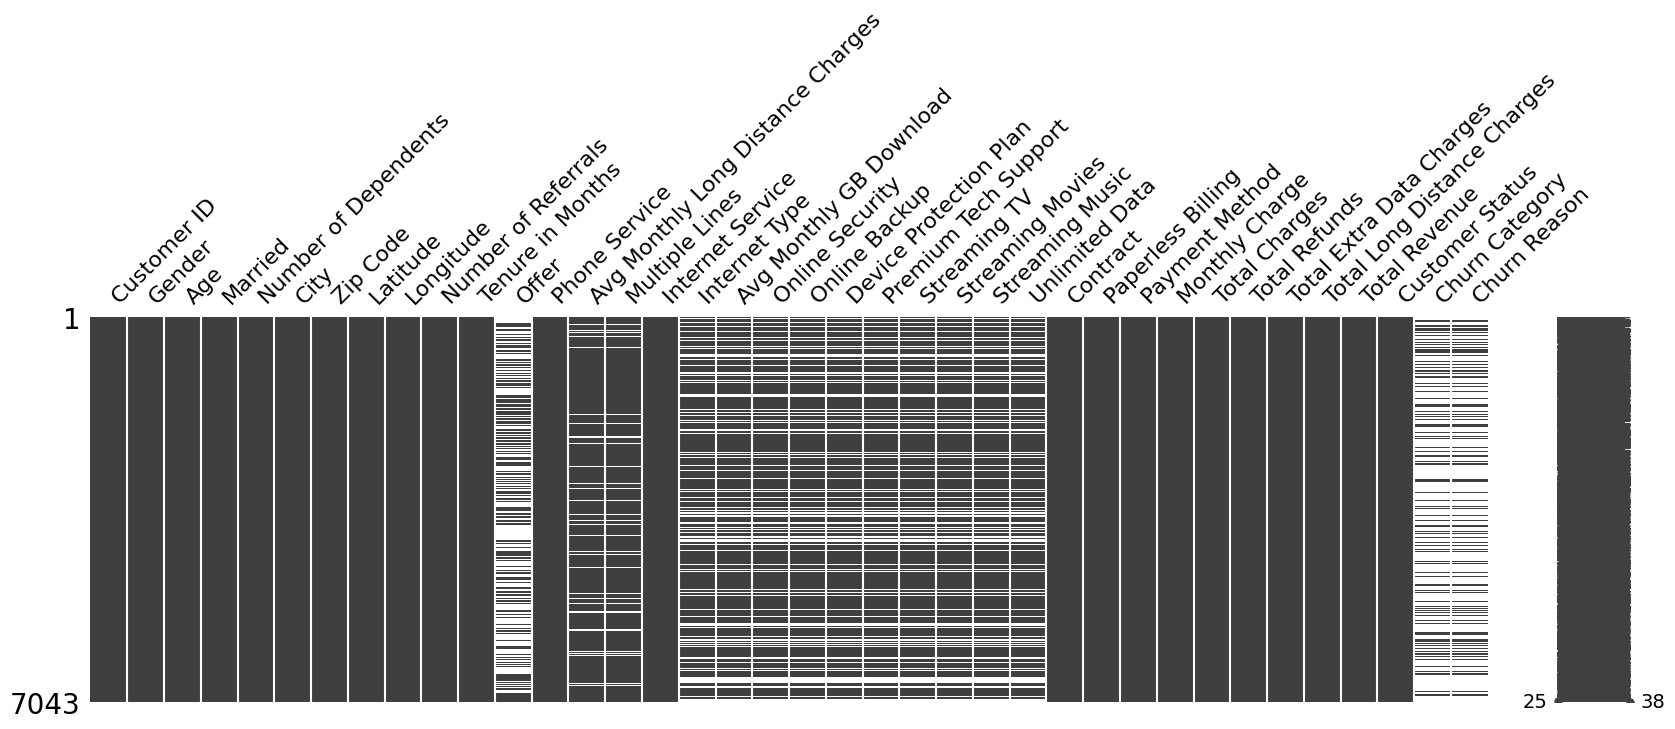

In [ ]:
msno.matrix(df, figsize=(20, 5))

## Data Manipulation

### Handling Missing Values

In [ ]:
# Replace 'No Internet service' and 'No phone service' with 'No' for consistency in relevant columns
internet_related_cols = [
    'Online Security', 'Online Backup', 'Device Protection Plan',
    'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
    'Streaming Music', 'Unlimited Data'
]
for col in internet_related_cols:
    df[col] = df[col].replace({'No internet service': 'No'}).fillna('No')

phone_related_cols = [
    'Multiple Lines'
]
for col in phone_related_cols:
    df[col] = df[col].replace({'No phone service': 'No'}).fillna('No')

# Fill NaN values in 'Internet Type' with 'No Internet' for customers without internet service
df['Internet Type'] = df['Internet Type'].fillna('No Internet')

# Fill NaN values in 'Avg Monthly GB Download' with 0 for customers without internet service
df['Avg Monthly GB Download'] = df['Avg Monthly GB Download'].fillna(0)

# Fill NaN values in 'Avg Monthly Long Distance Charges' with 0 for customers without phone service
df['Avg Monthly Long Distance Charges'] = df['Avg Monthly Long Distance Charges'].fillna(0)

# The 'Offer' column has many missing values (NaN). Since 'Offer' indicates if a customer received a promotional offer, 'NaN' can be interpreted as 'No Offer'.
df['Offer'] = df['Offer'].fillna('No Offer')

# For 'Churn Category' and 'Churn Reason', NaN values indicate customers who have not churned (i.e., 'Stayed').
df['Churn Category'] = df['Churn Category'].fillna('No Churn')
# 'Churn Reason' was already dropped, so this line will be removed to avoid KeyError
# df['Churn Reason'] = df['Churn Reason'].fillna('No Churn')

In [ ]:
# Re-checking info after modified missing value handling
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             7043 non-null   object 
 1   Age                                7043 non-null   int64  
 2   Married                            7043 non-null   object 
 3   Number of Dependents               7043 non-null   int64  
 4   City                               7043 non-null   object 
 5   Number of Referrals                7043 non-null   int64  
 6   Tenure in Months                   7043 non-null   int64  
 7   Offer                              7043 non-null   object 
 8   Phone Service                      7043 non-null   object 
 9   Avg Monthly Long Distance Charges  7043 non-null   float64
 10  Multiple Lines                     7043 non-null   object 
 11  Internet Service                   7043 non-null   objec

### Target Variable Distribution

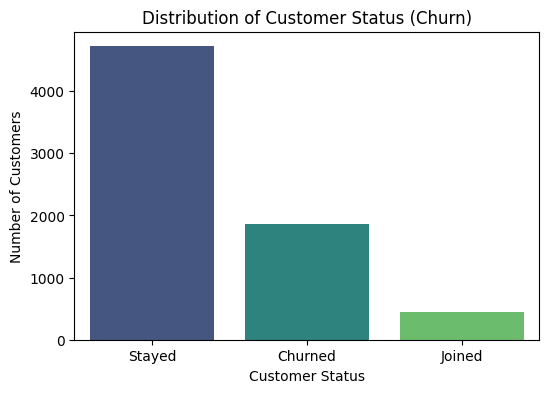

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Customer Status', palette='viridis')
plt.title('Distribution of Customer Status (Churn)')
plt.xlabel('Customer Status')
plt.ylabel('Number of Customers')
plt.show()

### Categorical Feature Distribution

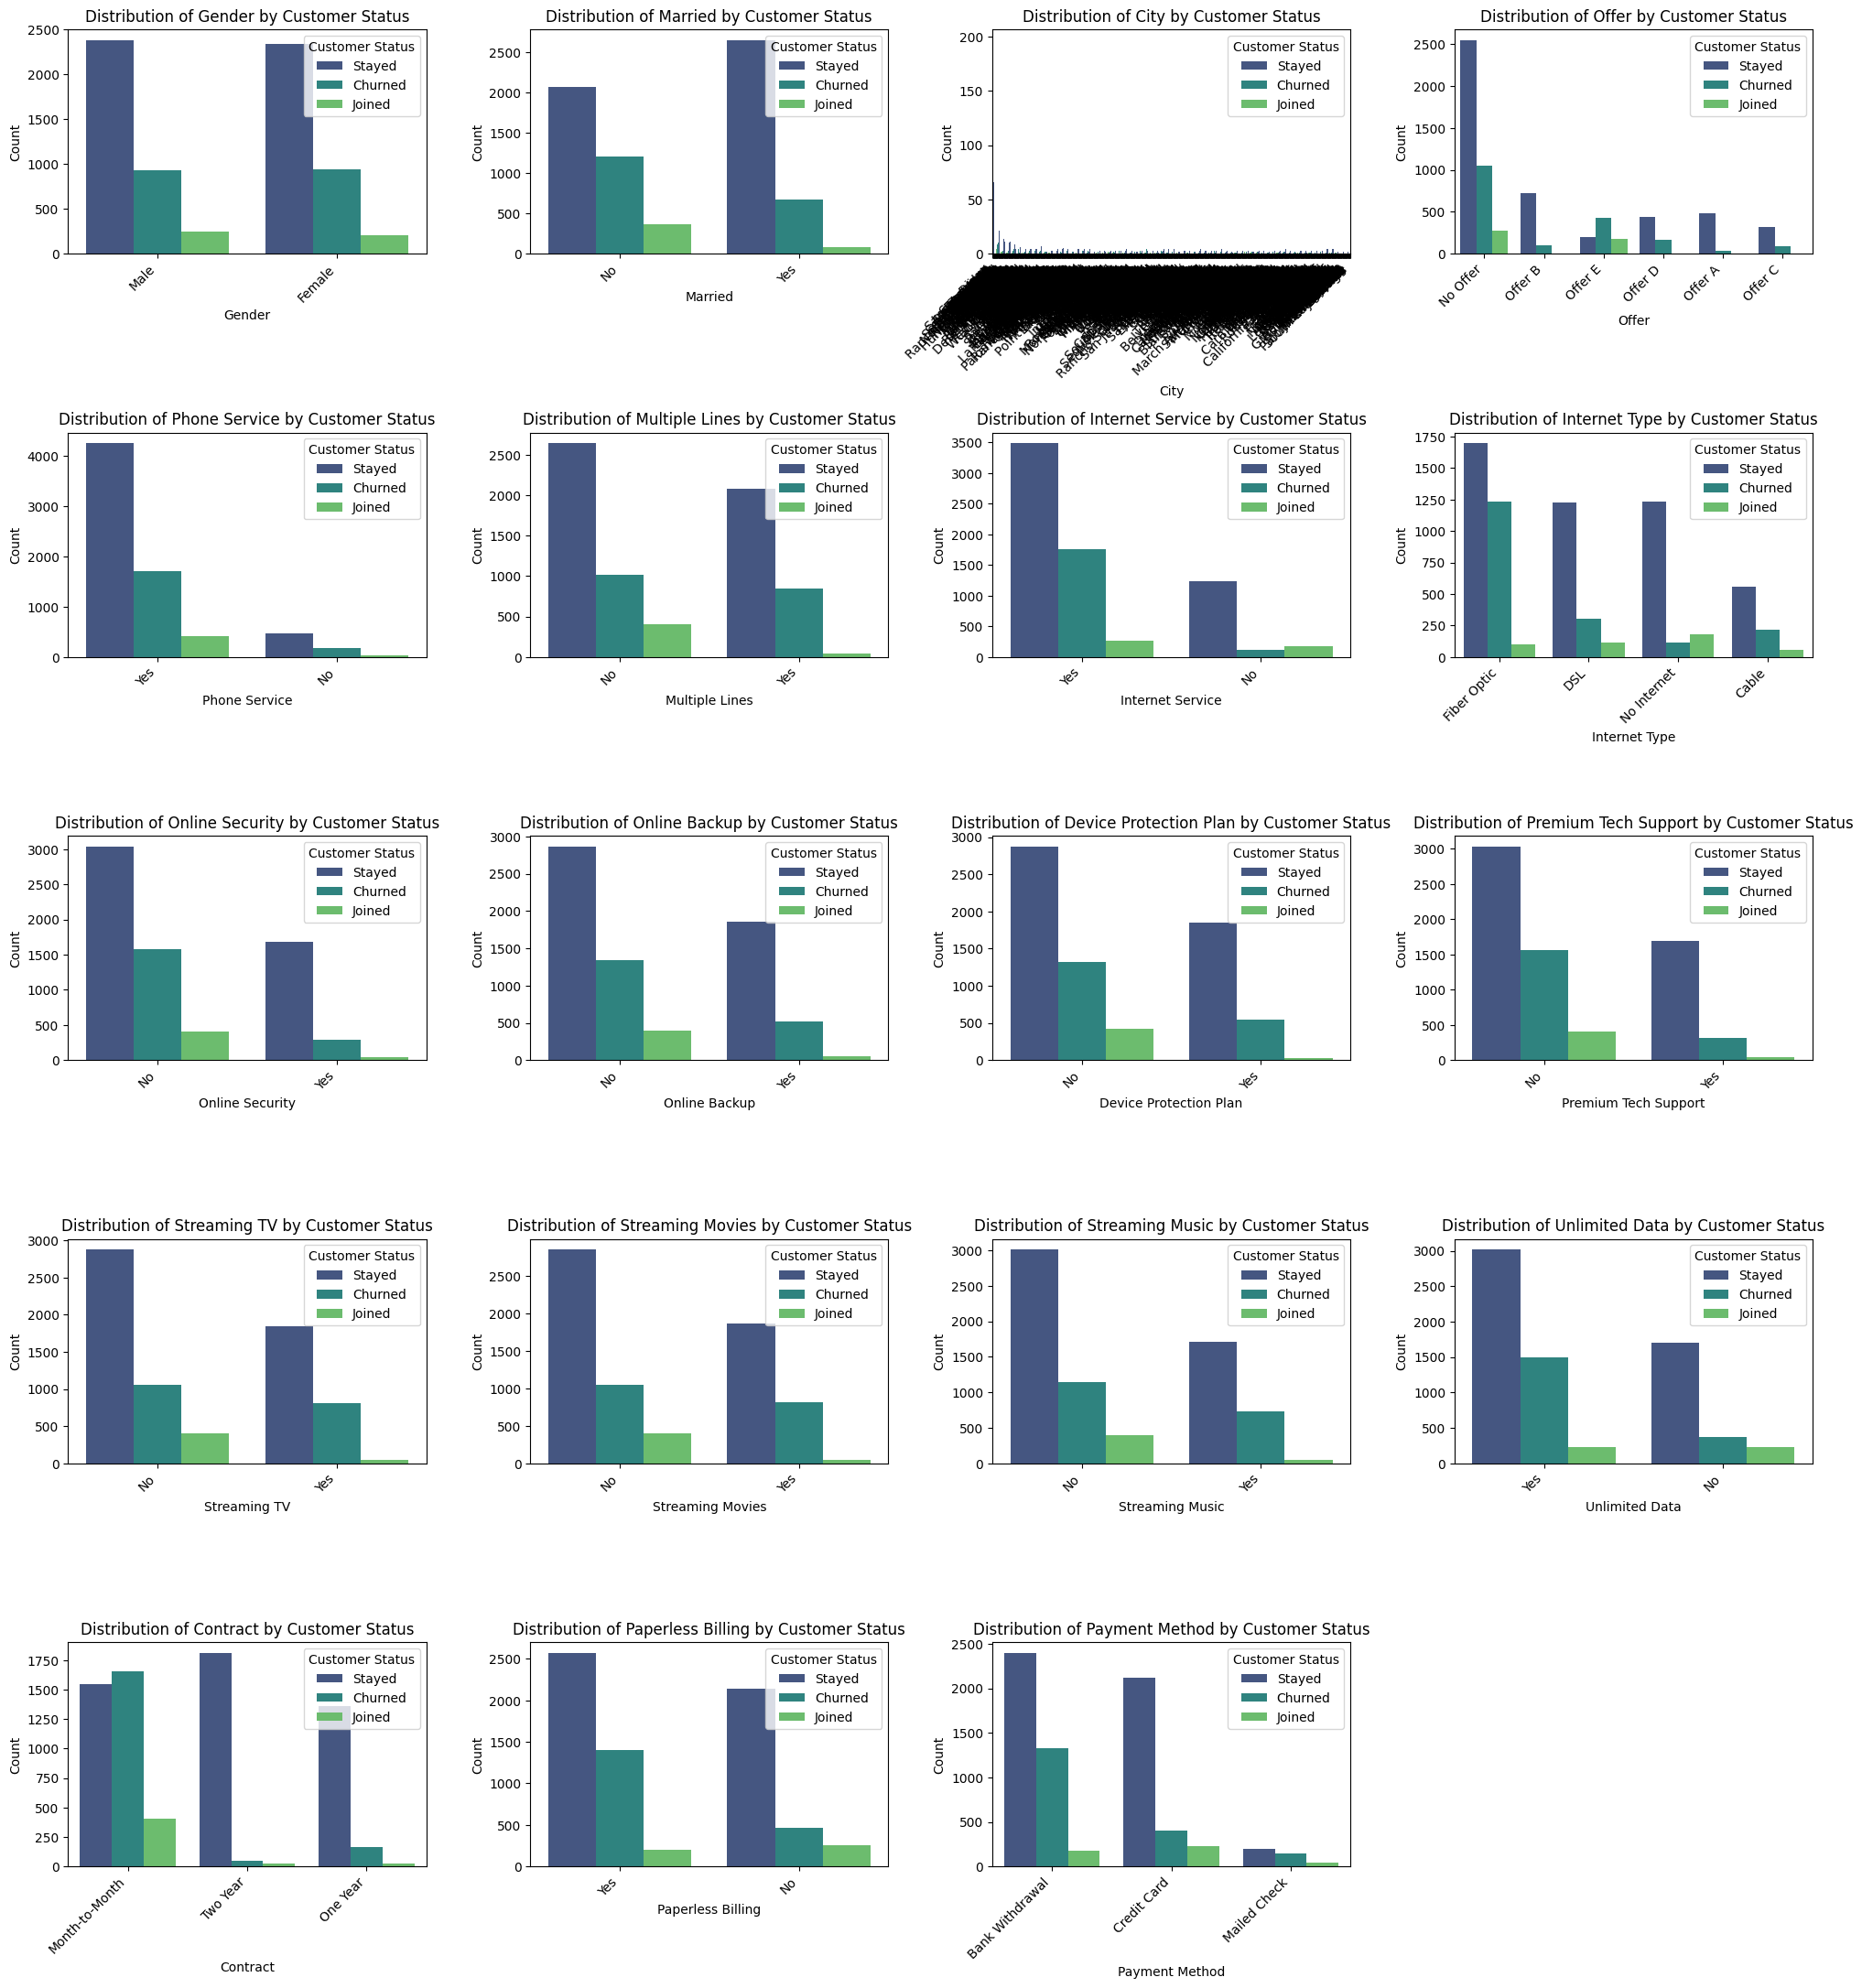

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
# Exclude 'Customer Status' and 'Churn Category' as they are target/related to target
categorical_cols.remove('Customer Status')
categorical_cols.remove('Churn Category')

plt.figure(figsize=(20, 25))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(6, 4, i)
    sns.countplot(data=df, x=col, hue='Customer Status', palette='viridis', order=df[col].value_counts().index)
    plt.title(f'Distribution of {col} by Customer Status')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Numerical Feature Distribution

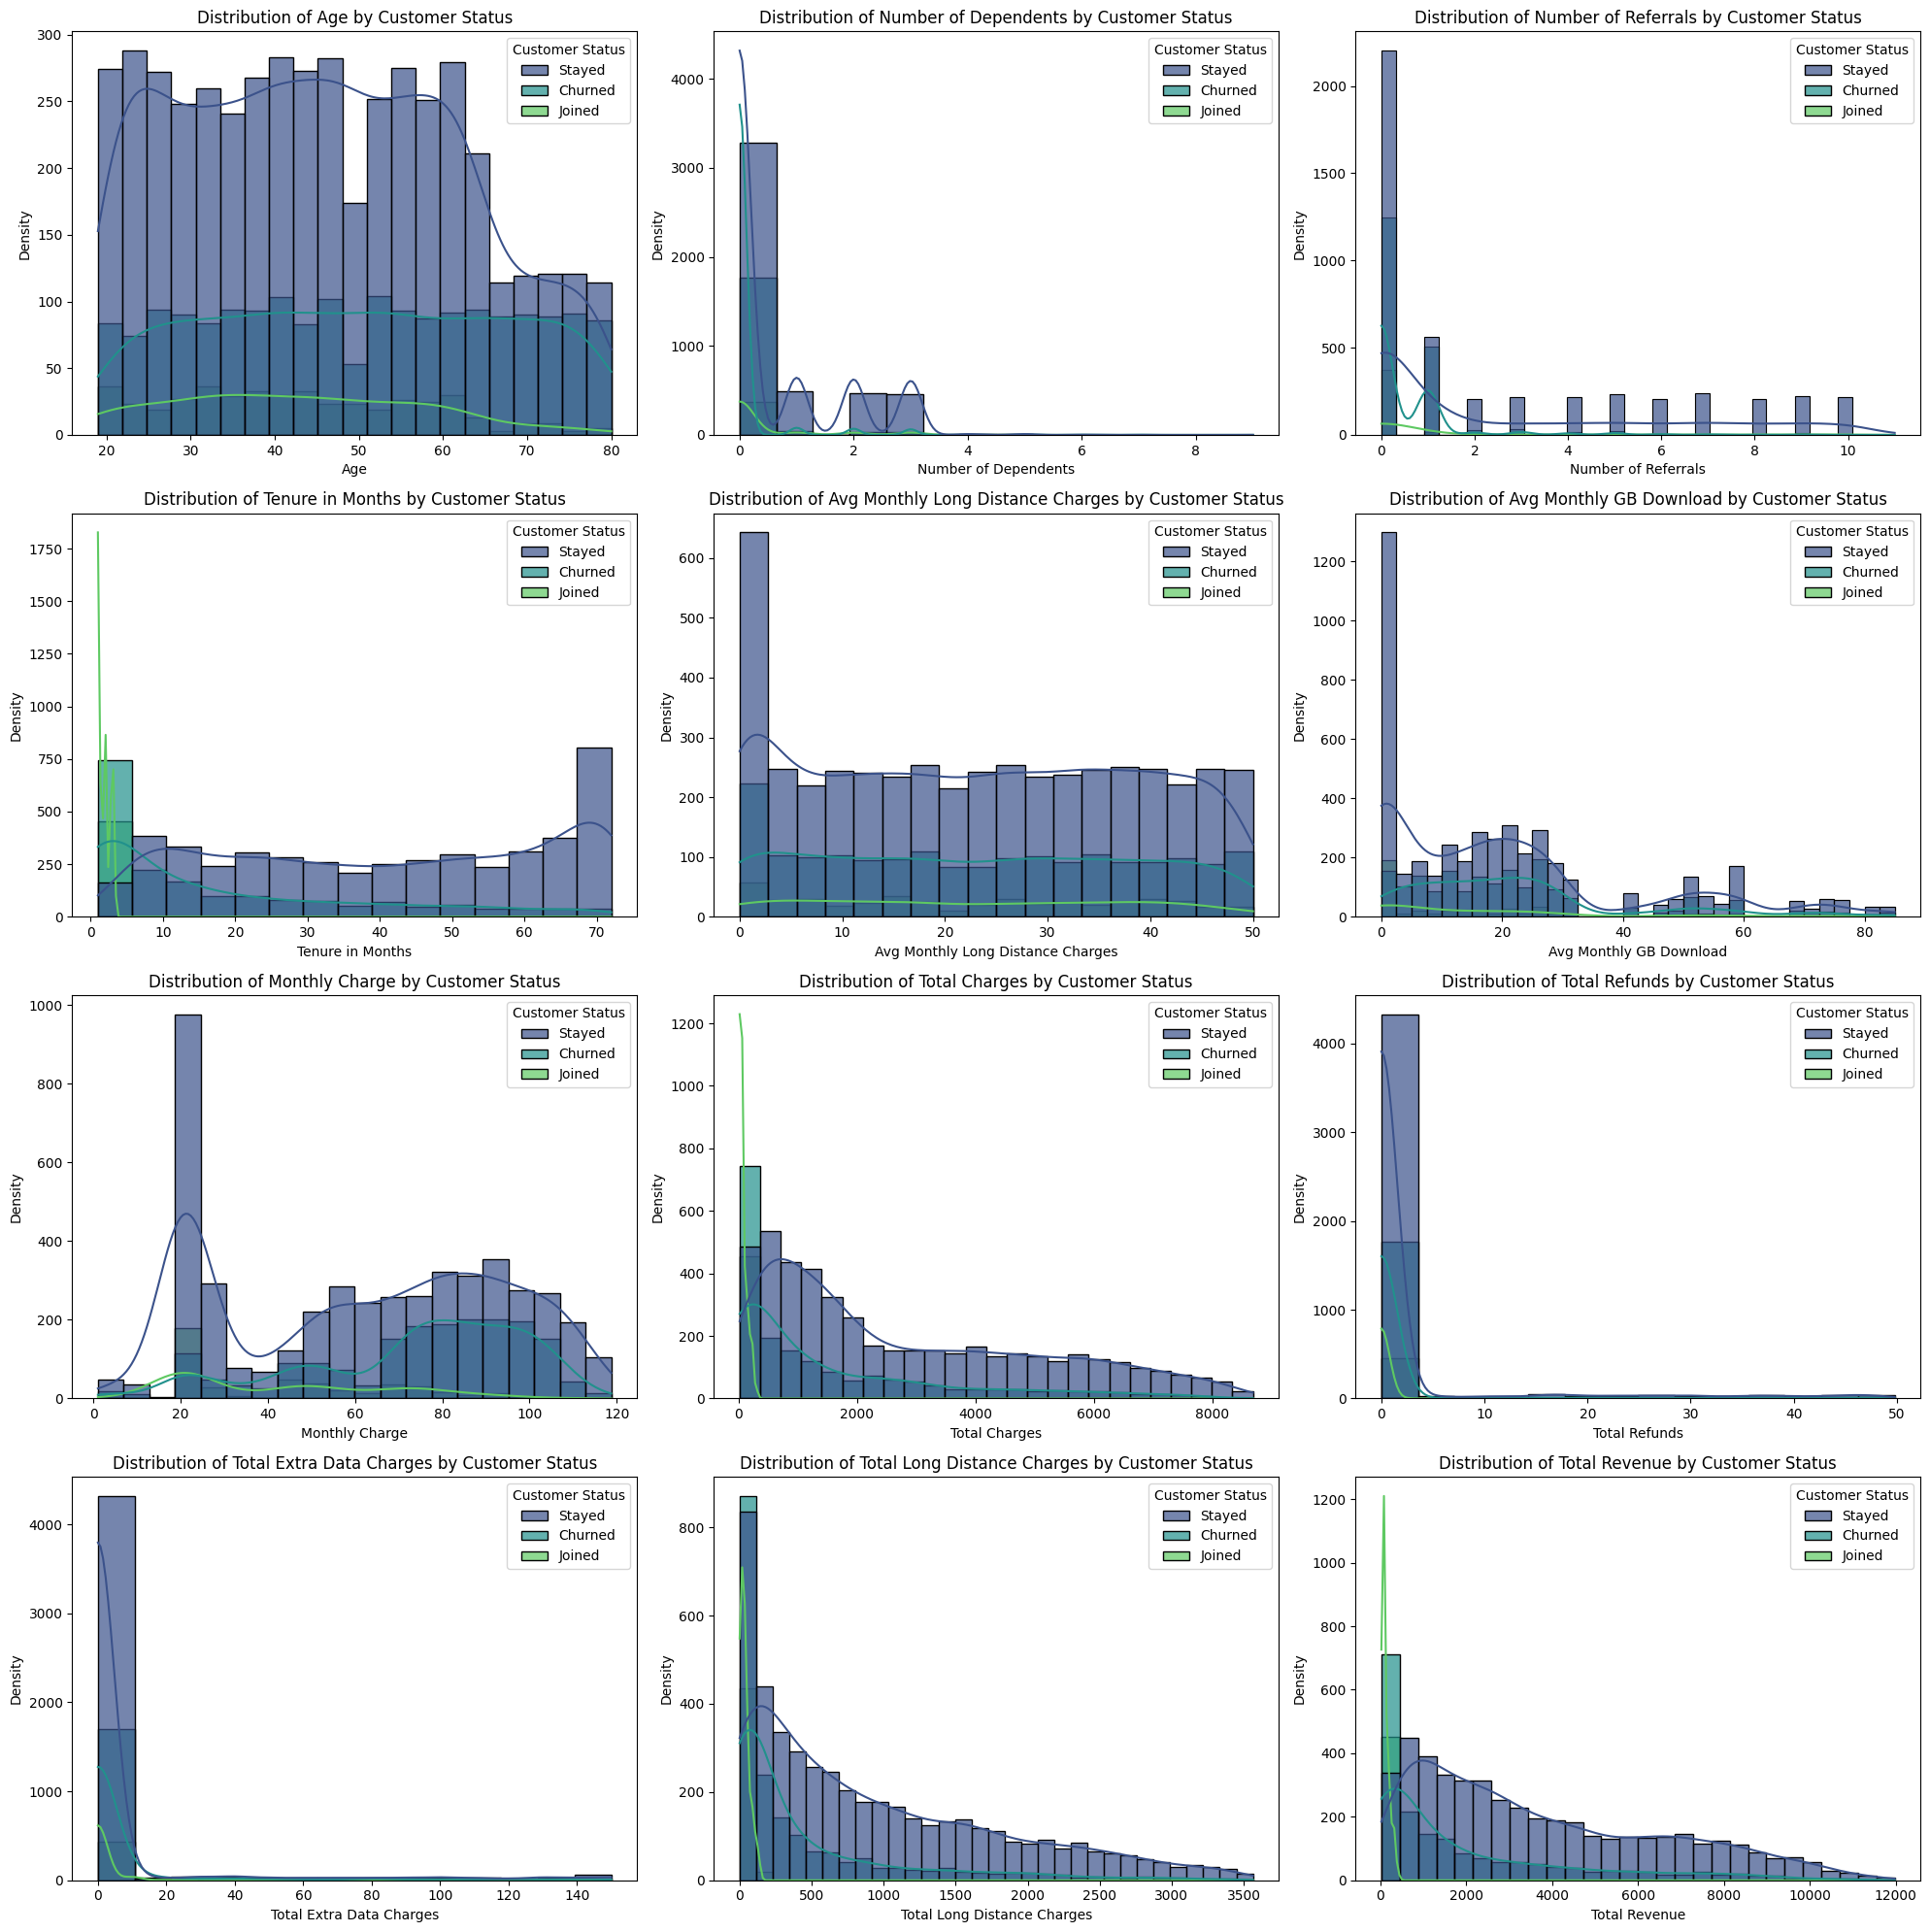

In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

plt.figure(figsize=(20, 20))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4, 3, i)
    sns.histplot(data=df, x=col, kde=True, hue='Customer Status', palette='viridis', alpha=0.7)
    plt.title(f'Distribution of {col} by Customer Status')
    plt.xlabel(col)
    plt.ylabel('Density')
plt.tight_layout()
plt.show()

## Data Preprocessing (Standardizing numeric attributes)

### Label Encoding Categorical Features

In [ ]:
le = LabelEncoder()

# Apply Label Encoding to binary and multi-class categorical columns
for col in categorical_cols:
    if df[col].nunique() == 2: # Binary categorical columns
        df[col] = le.fit_transform(df[col])
    else: # Multi-class categorical columns
        # For multi-class, we'll use one-hot encoding later for model compatibility
        # but for now, we can still encode them to numerical representations
        # for simplicity or if a model handles integer encoding well.
        # However, it's safer to leave them as-is for One-Hot Encoding later
        pass # We'll handle multi-class with One-Hot Encoding

### One-Hot Encoding for Multi-Class Categorical Features

In [ ]:
# Identify all object columns that are not the target variable ('Customer Status')
# for one-hot encoding. 'Customer Status' will be explicitly encoded later.
cols_to_onehot_encode = [col for col in df.select_dtypes(include='object').columns if col != 'Customer Status']

# Apply one-hot encoding to these columns
df = pd.get_dummies(df, columns=cols_to_onehot_encode, drop_first=True)

### Encoding Target Variable

In [ ]:
# Encode 'Customer Status' to numerical representation
# Stayed: 0, Churned: 1, Joined: 2
target_mapping = {'Stayed': 0, 'Churned': 1, 'Joined': 2}
df['Customer Status'] = df['Customer Status'].map(target_mapping)

### Feature Scaling (Standardization)

In [ ]:
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

### Review Processed Data

In [ ]:
df.head()

,Gender,Age,Married,Number of Dependents,Number of Referrals,Tenure in Months,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,...,Internet Type_No Internet,Contract_One Year,Contract_Two Year,Payment Method_Credit Card,Payment Method_Mailed Check,Churn Category_Competitor,Churn Category_Dissatisfaction,Churn Category_No Churn,Churn Category_Other,Churn Category_Price
0,0,-0.567773,1,-0.486835,0.016039,-0.952994,1,1.257916,0,1,...,False,True,False,True,False,False,False,True,False,False
1,1,-0.030433,0,-0.486835,-0.650409,-0.952994,1,-0.794260,1,1,...,False,False,False,True,False,False,False,True,False,False
2,1,0.208385,0,-0.486835,-0.650409,-1.156740,1,0.692111,0,1,...,False,False,False,False,False,True,False,False,False,False
3,1,1.880110,1,-0.486835,-0.317185,-0.789997,1,0.314692,0,1,...,False,False,False,False,False,False,True,False,False,False
4,0,1.700997,1,-0.486835,0.349263,-1.197489,1,-1.008541,0,1,...,False,False,False,True,False,False,True,False,False,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Columns: 1149 entries, Gender to Churn Category_Price
dtypes: bool(1122), float64(12), int64(15)
memory usage: 9.0 MB


## Machine Learning Model Evaluations and Predictions

### Splitting Data into Training and Testing Sets

In [ ]:
X = df.drop('Customer Status', axis=1)
y = df['Customer Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (5634, 1148)
X_test shape: (1409, 1148)
y_train shape: (5634,)
y_test shape: (1409,)


### Model Evaluation Function

In [ ]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)

    print(f"--- {model_name} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("\nConfusion Matrix:")
    print(cm)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return accuracy, report, cm

svc_model = SVC(random_state=42)
svc_accuracy, svc_report, svc_cm = evaluate_model(svc_model, X_train, y_train, X_test, y_test, 'Support Vector Classifier')

### Cross-Validation for Robust Model Evaluation

I'm going to perform k-fold cross-validation to assess the stability and generalization ability of our models, especially given the high accuracies observed. This will provide a more reliable estimate of performance by evaluating models on multiple train-test splits.

In [ ]:
from sklearn.model_selection import KFold, cross_val_score

def evaluate_model_with_cv(model, X, y, model_name, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

    print(f"--- Cross-Validation Scores for {model_name} (k={n_splits}) ---")
    print(f"Individual fold accuracies: {cv_scores}")
    print(f"Mean accuracy: {cv_scores.mean():.4f}")
    print(f"Standard deviation of accuracy: {cv_scores.std():.4f}")
    print("\n")
    return cv_scores.mean()


# I'm going to evaluate some of the models with cross-validation.
print("Starting Cross-Validation Evaluations...")

# Evaluate Decision Tree with CV
dtree_cv_accuracy = evaluate_model_with_cv(DecisionTreeClassifier(random_state=42), X, y, 'Decision Tree Classifier')

# Evaluate Gradient Boosting with CV
gb_cv_accuracy = evaluate_model_with_cv(GradientBoostingClassifier(random_state=42), X, y, 'Gradient Boosting Classifier')

# Evaluate Random Forest with CV
rf_cv_accuracy = evaluate_model_with_cv(RandomForestClassifier(random_state=42), X, y, 'Random Forest Classifier')

# Evaluate Logistic Regression with CV
lr_cv_accuracy = evaluate_model_with_cv(LogisticRegression(random_state=42, max_iter=1000), X, y, 'Logistic Regression')

# Evaluate K-Nearest Neighbors with CV (for comparison)
knn_cv_accuracy = evaluate_model_with_cv(KNeighborsClassifier(n_neighbors=5), X, y, 'K-Nearest Neighbors')

# I'm going to store the cross-validation results for comparison.
cv_results = {
    'Decision Tree': dtree_cv_accuracy,
    'Gradient Boosting': gb_cv_accuracy,
    'Random Forest': rf_cv_accuracy,
    'Logistic Regression': lr_cv_accuracy,
    'K-Nearest Neighbors': knn_cv_accuracy
}

print("Cross-Validation Results Summary:")
for model, accuracy in cv_results.items():
    print(f"{model}: {accuracy:.4f}")

Starting Cross-Validation Evaluations...
--- Cross-Validation Scores for Decision Tree Classifier (k=5) ---
Individual fold accuracies: [1. 1. 1. 1. 1.]
Mean accuracy: 1.0000
Standard deviation of accuracy: 0.0000


--- Cross-Validation Scores for Gradient Boosting Classifier (k=5) ---
Individual fold accuracies: [1. 1. 1. 1. 1.]
Mean accuracy: 1.0000
Standard deviation of accuracy: 0.0000


--- Cross-Validation Scores for Random Forest Classifier (k=5) ---
Individual fold accuracies: [0.99290277 0.99716111 0.99574166 0.99786932 0.99644886]
Mean accuracy: 0.9960
Standard deviation of accuracy: 0.0017


--- Cross-Validation Scores for Logistic Regression (k=5) ---
Individual fold accuracies: [0.99219304 0.99006388 0.99361249 0.99147727 0.9921875 ]
Mean accuracy: 0.9919
Standard deviation of accuracy: 0.0012


--- Cross-Validation Scores for K-Nearest Neighbors (k=5) ---
Individual fold accuracies: [0.89354152 0.8899929  0.89779986 0.88210227 0.89488636]
Mean accuracy: 0.8917
Standard de

### Random Forest Classifier

I'm going to evaluate the Random Forest Classifier. This ensemble method is excellent for handling complex datasets and reducing overfitting by combining multiple decision trees.

--- Random Forest Classifier ---
Accuracy: 0.9986

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       944
           1       1.00      1.00      1.00       374
           2       1.00      0.99      0.99        91

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409


Confusion Matrix:
[[944   0   0]
 [  1 373   0]
 [  1   0  90]]


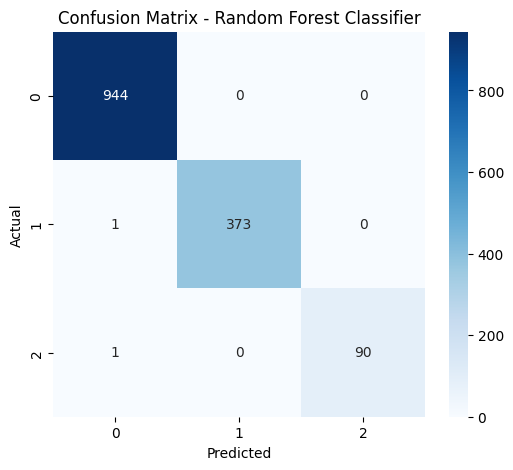

In [ ]:
rf_model = RandomForestClassifier(random_state=42)
rf_accuracy, rf_report, rf_cm = evaluate_model(rf_model, X_train, y_train, X_test, y_test, 'Random Forest Classifier')

### Logistic Regression

I'm going to evaluate the Logistic Regression model. Despite its name, it's a linear model used for classification, and it's a good baseline for many classification tasks.

--- Logistic Regression ---
Accuracy: 0.9908

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       944
           1       1.00      1.00      1.00       374
           2       0.91      0.96      0.93        91

    accuracy                           0.99      1409
   macro avg       0.97      0.98      0.97      1409
weighted avg       0.99      0.99      0.99      1409


Confusion Matrix:
[[935   0   9]
 [  0 374   0]
 [  4   0  87]]


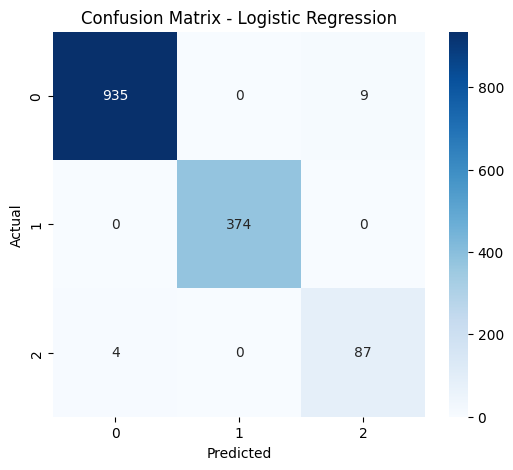

In [ ]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_accuracy, lr_report, lr_cm = evaluate_model(lr_model, X_train, y_train, X_test, y_test, 'Logistic Regression')

### Decision Tree Classifier

I'm going to evaluate the Decision Tree Classifier. This model creates a tree-like structure of decisions to classify instances and is relatively easy to interpret.

--- Decision Tree Classifier ---
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       944
           1       1.00      1.00      1.00       374
           2       1.00      1.00      1.00        91

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409


Confusion Matrix:
[[944   0   0]
 [  0 374   0]
 [  0   0  91]]


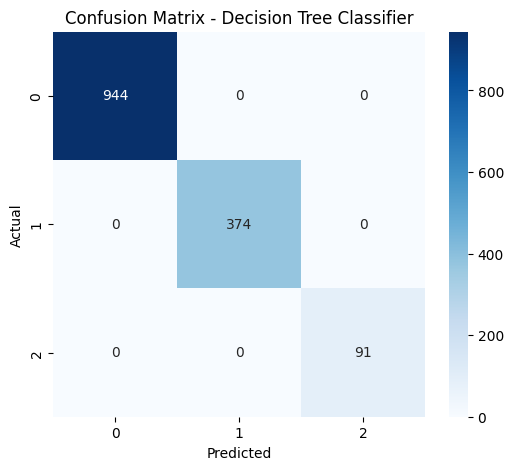

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_accuracy, dt_report, dt_cm = evaluate_model(dt_model, X_train, y_train, X_test, y_test, 'Decision Tree Classifier')

### AdaBoost Classifier

I'm going to evaluate the AdaBoost Classifier. This boosting algorithm combines multiple weak learners (often decision trees) to create a strong classifier.

--- AdaBoost Classifier ---
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       944
           1       1.00      1.00      1.00       374
           2       1.00      1.00      1.00        91

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409


Confusion Matrix:
[[944   0   0]
 [  0 374   0]
 [  0   0  91]]


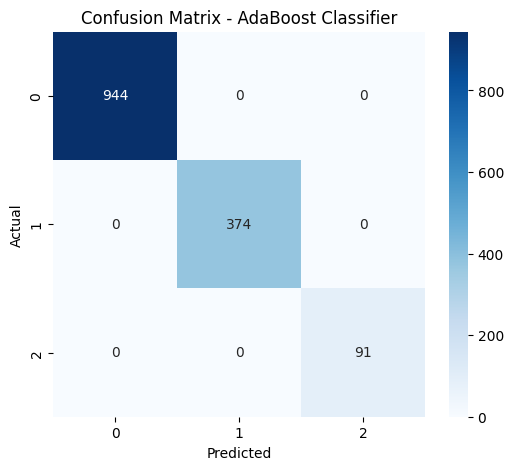

In [ ]:
ab_model = AdaBoostClassifier(random_state=42)
ab_accuracy, ab_report, ab_cm = evaluate_model(ab_model, X_train, y_train, X_test, y_test, 'AdaBoost Classifier')

### Gradient Boosting Classifier

I'm going to evaluate the Gradient Boosting Classifier. Similar to AdaBoost, this model builds trees sequentially, but it tries to correct the errors of the previous trees by focusing on misclassified instances.

--- Gradient Boosting Classifier ---
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       944
           1       1.00      1.00      1.00       374
           2       1.00      1.00      1.00        91

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409


Confusion Matrix:
[[944   0   0]
 [  0 374   0]
 [  0   0  91]]


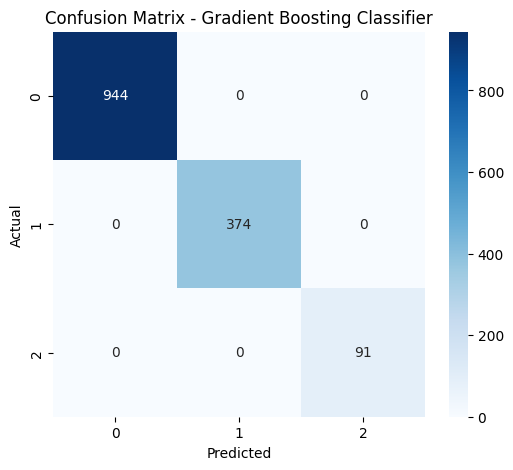

In [ ]:
gb_model = GradientBoostingClassifier(random_state=42)
gb_accuracy, gb_report, gb_cm = evaluate_model(gb_model, X_train, y_train, X_test, y_test, 'Gradient Boosting Classifier')

### Voting Classifier

I'm going to evaluate a Voting Classifier. This ensemble method combines the predictions of multiple diverse models (in this case, Logistic Regression, Random Forest, and Gradient Boosting) to achieve better performance and robustness.

--- Voting Classifier ---
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       944
           1       1.00      1.00      1.00       374
           2       1.00      1.00      1.00        91

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409


Confusion Matrix:
[[944   0   0]
 [  0 374   0]
 [  0   0  91]]


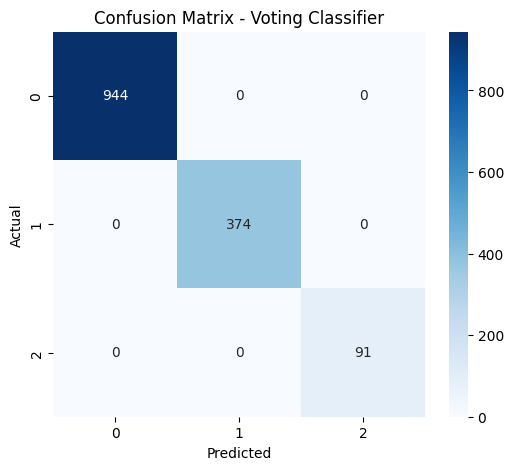

In [ ]:
from sklearn.ensemble import VotingClassifier

# Instantiate base models for the Voting Classifier
voting_clf = VotingClassifier(
    estimators=[('lr', LogisticRegression(random_state=42, max_iter=1000)),
                ('rf', RandomForestClassifier(random_state=42)),
                ('gb', GradientBoostingClassifier(random_state=42))],
    voting='soft'  # 'soft' for probability-based voting
)

voting_accuracy, voting_report, voting_cm = evaluate_model(voting_clf, X_train, y_train, X_test, y_test, 'Voting Classifier')

--- K-Nearest Neighbors ---
Accuracy: 0.8864

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       944
           1       0.96      0.82      0.88       374
           2       0.53      0.46      0.49        91

    accuracy                           0.89      1409
   macro avg       0.79      0.74      0.77      1409
weighted avg       0.89      0.89      0.88      1409


Confusion Matrix:
[[902  10  32]
 [ 64 305   5]
 [ 46   3  42]]


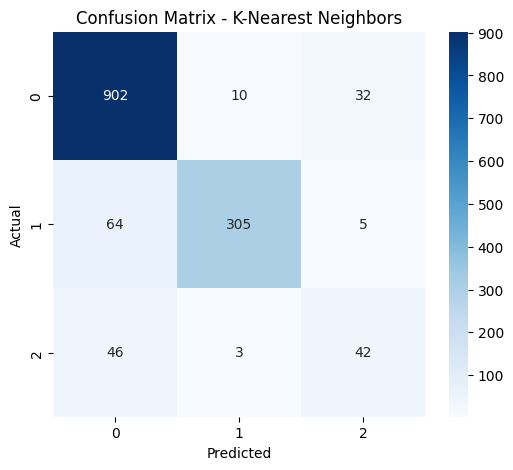

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_accuracy, knn_report, knn_cm = evaluate_model(knn_model, X_train, y_train, X_test, y_test, 'K-Nearest Neighbors')

### Support Vector Classifier (SVC)

I'm going to evaluate the Support Vector Classifier (SVC) model next. This model is known for its effectiveness in high-dimensional spaces and its versatility through kernel functions.

## Machine Learning Model Evaluations and Predictions

### Splitting Data into Training and Testing Sets

In [ ]:
X = df.drop('Customer Status', axis=1)
y = df['Customer Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (5634, 1144)
X_test shape: (1409, 1144)
y_train shape: (5634,)
y_test shape: (1409,)


### Correcting Data Types and Values

In [ ]:
# Correct the negative 'Monthly Charge' values by taking their absolute value
df['Monthly Charge'] = df['Monthly Charge'].abs()

# Convert 'Total Charges' to numeric, coercing errors to NaN
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

# Fill any NaN values created by the conversion in 'Total Charges' (these would typically be customers with 0 tenure) with 0
df['Total Charges'] = df['Total Charges'].fillna(0)

### Dropping Irrelevant Columns

In [ ]:
# Drop 'Customer ID', 'Zip Code', 'Latitude', 'Longitude' as they are not directly useful for churn prediction and can introduce noise or bias.
df = df.drop(columns=['Customer ID', 'Zip Code', 'Latitude', 'Longitude'])

# Drop 'Churn Reason' as 'Churn Category' is more generalized and sufficient for this analysis.
df = df.drop(columns=['Churn Reason'])

# Re-check the info to confirm changes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             7043 non-null   object 
 1   Age                                7043 non-null   int64  
 2   Married                            7043 non-null   object 
 3   Number of Dependents               7043 non-null   int64  
 4   City                               7043 non-null   object 
 5   Number of Referrals                7043 non-null   int64  
 6   Tenure in Months                   7043 non-null   int64  
 7   Offer                              7043 non-null   object 
 8   Phone Service                      7043 non-null   object 
 9   Avg Monthly Long Distance Charges  7043 non-null   float64
 10  Multiple Lines                     6361 non-null   object 
 11  Internet Service                   7043 non-null   objec

## Data Visualization

### Target Variable Distribution

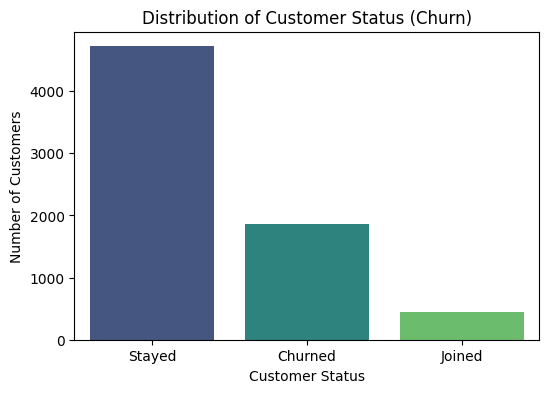

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Customer Status', palette='viridis')
plt.title('Distribution of Customer Status (Churn)')
plt.xlabel('Customer Status')
plt.ylabel('Number of Customers')
plt.show()

In [ ]:
internet_related_cols = [
    'Online Security', 'Online Backup', 'Device Protection Plan',
    'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
    'Streaming Music', 'Unlimited Data'
]
for col in internet_related_cols:
    df[col] = df[col].replace({'No internet service': 'No'})

phone_related_cols = [
    'Multiple Lines'
]
for col in phone_related_cols:
    df[col] = df[col].replace({'No phone service': 'No'})

df['Internet Type'] = df['Internet Type'].fillna('No Internet')
df['Avg Monthly GB Download'] = df['Avg Monthly GB Download'].fillna(0)
df['Avg Monthly Long Distance Charges'] = df['Avg Monthly Long Distance Charges'].fillna(0)
df['Offer'] = df['Offer'].fillna('No Offer')
df['Churn Category'] = df['Churn Category'].fillna('No Churn')
df['Churn Reason'] = df['Churn Reason'].fillna('No Churn')

KeyError: 'Churn Reason'

In [ ]:
df['Monthly Charge'] = df['Monthly Charge'].abs()
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'] = df['Total Charges'].fillna(0)